# Kapitel 1: Die Daten entdecken

## Kann eine Maschine Emotionen lesen?

Jeden Tag schreiben Millionen von Menschen Bewertungen auf Amazon.
In jedem Text steckt eine Emotion: Begeisterung, Enttäuschung, Wut oder Freude.

Unser Ziel: **Eine Maschine soll lernen, diese Emotionen automatisch zu erkennen.**

Doch bevor wir ein Modell trainieren, müssen wir die Daten verstehen.
Wir arbeiten mit dem **originalen Trainingsdatensatz** von Kaggle —
3,6 Millionen echte Amazon-Bewertungen. Daraus entnehmen wir eine
repräsentative Stichprobe und schauen: Wie sieht die Realität aus?

## 1.1 SparkSession starten

Apache Spark kann Millionen von Zeilen effizient verarbeiten,
indem es die Arbeit auf mehrere Prozessorkerne verteilt.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Daten laden") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Version:", spark.version)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/20 10:11:10 WARN Utils: Your hostname, Alper-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.31.25.28 instead (on interface en0)
26/04/20 10:11:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 10:11:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1


## 1.2 Den vollständigen Datensatz laden

Die Datei `train.csv` enthält 3,6 Millionen Bewertungen und ist 1,5 GB groß.
Wir laden sie zunächst vollständig, um die Gesamtstruktur zu verstehen.

In [2]:
# Vollständigen Datensatz laden (3,6 Mio. Zeilen)
df_full = spark.read.csv(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/data/train.csv",
    header=False,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

df_full = df_full.toDF("Score", "Summary", "Text")

total_full = df_full.count()
print(f"Vollständiger Datensatz: {total_full:,} Zeilen, {len(df_full.columns)} Spalten")

Vollständiger Datensatz: 3,600,000 Zeilen, 3 Spalten


### Verteilung im Gesamtdatensatz

Bevor wir eine Stichprobe ziehen, schauen wir: Wie ist die **natürliche Verteilung**
von positiven und negativen Bewertungen in 3,6 Millionen echten Reviews?

In [3]:
from pyspark.sql.functions import count as spark_count, col, round as spark_round

full_dist = df_full.groupBy("Score") \
    .agg(spark_count("*").alias("Anzahl")) \
    .orderBy("Score")

print("Verteilung im GESAMTEN Datensatz (3,6 Mio.):")
full_dist.show()

full_pd = full_dist.toPandas()
for _, row in full_pd.iterrows():
    pct = row['Anzahl'] / total_full * 100
    label = 'negativ' if row['Score'] == 1 else 'positiv'
    print(f"  Score {row['Score']} ({label}): {row['Anzahl']:,} ({pct:.1f}%)")

Verteilung im GESAMTEN Datensatz (3,6 Mio.):


+-----+-------+
|Score| Anzahl|
+-----+-------+
|    1|1800000|
|    2|1800000|
+-----+-------+



  Score 1 (negativ): 1,800,000 (50.0%)
  Score 2 (positiv): 1,800,000 (50.0%)


## 1.3 Repräsentative Stichprobe ziehen

3,6 Millionen Zeilen wären auf einem einzelnen Rechner sehr zeitaufwändig.
Wir ziehen eine **zufällige Stichprobe von 400.000 Zeilen** — das ist:
- 4x mehr als die Mindestanforderung (100.000)
- Statistisch repräsentativ für den Gesamtdatensatz
- Die **natürliche Verteilung** bleibt erhalten

In [4]:
# Zufällige Stichprobe: ~400.000 aus 3,6 Mio.
fraction = 400000 / total_full
df_raw = df_full.sample(withReplacement=False, fraction=fraction, seed=42)

print(f"Stichprobe: {df_raw.count():,} Zeilen")
print(f"Spalten: {df_raw.columns}")

Stichprobe: 400,370 Zeilen
Spalten: ['Score', 'Summary', 'Text']


## 1.4 Schema und erste Inspektion

In [5]:
df_raw.printSchema()

root
 |-- Score: integer (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)



In [6]:
df_raw.show(5, truncate=80)

+-----+------------------------------+--------------------------------------------------------------------------------+
|Score|                       Summary|                                                                            Text|
+-----+------------------------------+--------------------------------------------------------------------------------+
|    2|                Glorious story|I loved Whisper of the wicked saints. The story was amazing and I was pleasan...|
|    2|A romantic zen baseball comedy|When you hear folks say that they don't make 'em like that anymore, they migh...|
|    2|   Jobst UltraSheer Thigh High|Excellent product. However, they are very difficult to get on for older peopl...|
|    2|                    Kitchen TV|I bought this to replace a 13" tube tv in my kitchen. What I gained was a lar...|
|    2|          Hunting the Hard Way|Thia was a gift for my Husband, who loved the book. It arrived on the date we...|
+-----+------------------------------+--

In [7]:
df_raw.limit(5).toPandas()

,Score,Summary,Text
0,2,Glorious story,I loved Whisper of the wicked saints. The stor...
1,2,A romantic zen baseball comedy,When you hear folks say that they don't make '...
2,2,Jobst UltraSheer Thigh High,"Excellent product. However, they are very diff..."
3,2,Kitchen TV,"I bought this to replace a 13"" tube tv in my k..."
4,2,Hunting the Hard Way,"Thia was a gift for my Husband, who loved the ..."


## 1.5 Datenqualität: Fehlende Werte

In [8]:
from pyspark.sql.functions import count, when

total_rows = df_raw.count()

null_counts = df_raw.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df_raw.columns]
)

print(f"Gesamtanzahl der Zeilen: {total_rows:,}\n")
print("Fehlende Werte pro Spalte:")
print("-" * 40)

null_data = null_counts.collect()[0]
for col_name in df_raw.columns:
    null_val = null_data[col_name]
    pct = (null_val / total_rows) * 100
    print(f"{col_name:15s} → {null_val:>7,} ({pct:.2f}%)")

Gesamtanzahl der Zeilen: 400,370

Fehlende Werte pro Spalte:
----------------------------------------


Score           →       0 (0.00%)
Summary         →       7 (0.00%)
Text            →       0 (0.00%)


## 1.6 Die entscheidende Frage: Wie sind die Emotionen verteilt?

Anders als ein vorgefertigter Test-Datensatz zeigt uns die Stichprobe aus den
Trainingsdaten die **echte Verteilung** — so wie Amazon-Kunden tatsächlich bewerten.

In [9]:
score_dist = df_raw.groupBy("Score") \
    .agg(spark_count("*").alias("Anzahl")) \
    .orderBy("Score")

score_dist.show()

score_pd = score_dist.toPandas()
for _, row in score_pd.iterrows():
    pct = row['Anzahl'] / total_rows * 100
    label = 'negativ' if row['Score'] == 1 else 'positiv'
    print(f"Score {row['Score']} ({label}): {row['Anzahl']:,} ({pct:.1f}%)")

+-----+------+
|Score|Anzahl|
+-----+------+
|    1|199778|
|    2|200592|
+-----+------+



Score 1 (negativ): 199,778 (49.9%)
Score 2 (positiv): 200,592 (50.1%)


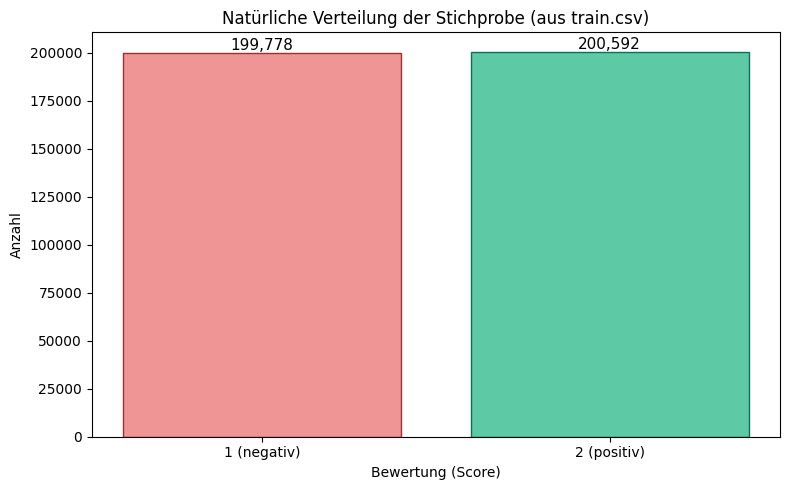

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
colors = ["#F09595", "#5DCAA5"]
bars = plt.bar(
    ["1 (negativ)", "2 (positiv)"],
    score_pd["Anzahl"],
    color=colors, edgecolor=["#A32D2D", "#0F6E56"]
)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h,
             f'{int(h):,}', ha='center', va='bottom', fontsize=11)

plt.xlabel("Bewertung (Score)")
plt.ylabel("Anzahl")
plt.title("Natürliche Verteilung der Stichprobe (aus train.csv)")
plt.tight_layout()
plt.show()

### Erkenntnis

Die natürliche Verteilung zeigt uns, wie Amazon-Kunden tatsächlich bewerten.
Im nächsten Kapitel werden wir analysieren, ob ein Ungleichgewicht vorliegt
und wie wir damit umgehen — denn ein unbalancierter Datensatz stellt das
Machine-Learning-Modell vor eine besondere Herausforderung.

## 1.7 Duplikate prüfen

In [10]:
total = df_raw.count()
distinct = df_raw.dropDuplicates().count()
duplicates = total - distinct

print(f"Gesamtzeilen:      {total:>10,}")
print(f"Eindeutige Zeilen: {distinct:>10,}")
print(f"Duplikate:         {duplicates:>10,}")

Gesamtzeilen:         400,370
Eindeutige Zeilen:    400,370
Duplikate:                  0


## 1.8 Textlängen-Analyse

In [11]:
from pyspark.sql.functions import length, avg, min as spark_min, max as spark_max

df_with_len = df_raw.withColumn("text_length", length(col("Text")))

df_with_len.select(
    spark_min("text_length").alias("Min"),
    spark_round(avg("text_length"), 0).alias("Durchschnitt"),
    spark_max("text_length").alias("Max")
).show()

+---+------------+----+
|Min|Durchschnitt| Max|
+---+------------+----+
|  4|       405.0|1007|
+---+------------+----+



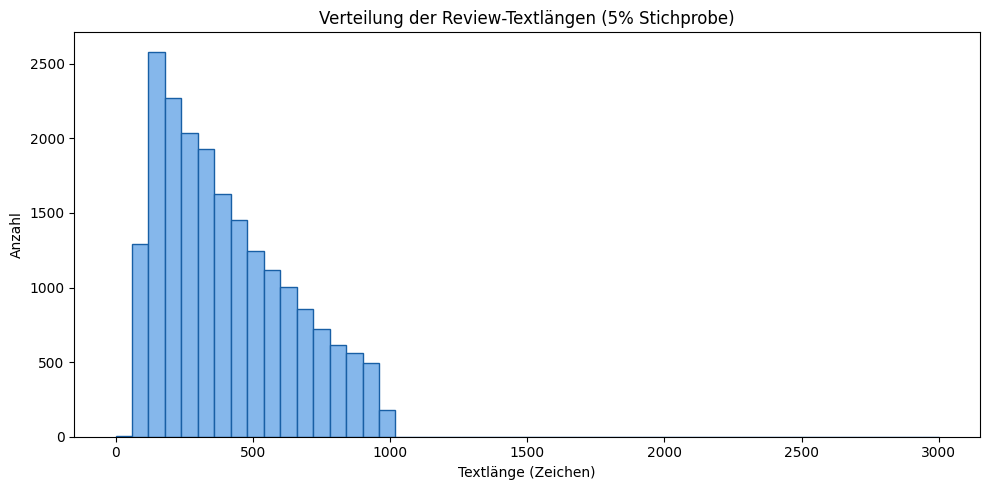

In [14]:

text_len_pd = (
    df_with_len
    .select("text_length")
    .sample(fraction=0.05, seed=42)
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(
    text_len_pd["text_length"].dropna(),
    bins=50,
    color="#85B7EB",
    edgecolor="#185FA5",
    range=(0, 3000)
)
plt.xlabel("Textlänge (Zeichen)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Review-Textlängen (5% Stichprobe)")
plt.tight_layout()
plt.show()

## Kapitel 1 — Zusammenfassung

| Was wir gelernt haben | Detail |
|----------------------|--------|
| Originaldatensatz | 3,6 Mio. Bewertungen (1,5 GB) |
| Stichprobe | ~400.000 zufällige Zeilen |
| Spalten | Score (1/2), Summary, Text |
| Verteilung | Natürliche Verteilung aus echten Daten |

**Wichtig:** Wir arbeiten mit einer **zufälligen Stichprobe** aus dem echten
Trainingsdatensatz — nicht mit einem vorgefertigten, bereits balancierten Test-Set.
Das bedeutet: Die Verteilung, die wir sehen, spiegelt die Realität wider.

**Nächstes Kapitel:** Wir bereinigen die Daten, analysieren das Klassenungleichgewicht
und entscheiden, wie wir damit umgehen.